# Locally Weighted Linear Regression (LWLR)

"""
This notebook explains Locally Weighted Linear Regression.

It extends Linear Regression by allowing the model to focus more on
nearby data points when making predictions.

Notebook Structure:

1. Concept
2. Math
3. Visualization
4. Code Implementation
5. Experiment
6. Summary
"""

# CONCEPT

"""

In normal Linear Regression we fit ONE line across the entire dataset.

Example:
House Price vs House Size

But sometimes relationships are not perfectly linear.

Example:
A dataset may behave differently in different regions.

Instead of fitting ONE global model, we can fit a LOCAL model
for each prediction.

Idea:

Nearby points should matter more.
Far points should matter less.

Locally Weighted Linear Regression does exactly this.

Each prediction creates its own local regression model.

"""

# MATH

"""

Normal Linear Regression Cost Function:

J(θ) = (1/2m) Σ (h(x_i) − y_i)^2


Locally Weighted Linear Regression modifies it by adding weights:

J(θ) = Σ w_i (h(x_i) − y_i)^2


Weight function:

w_i = exp( - (x_i − x_query)^2 / (2τ^2) )

Where:

x_query = point we want to predict
τ = bandwidth parameter


Interpretation:

If a point is CLOSE to the query point → high weight
If a point is FAR from the query point → low weight

"""

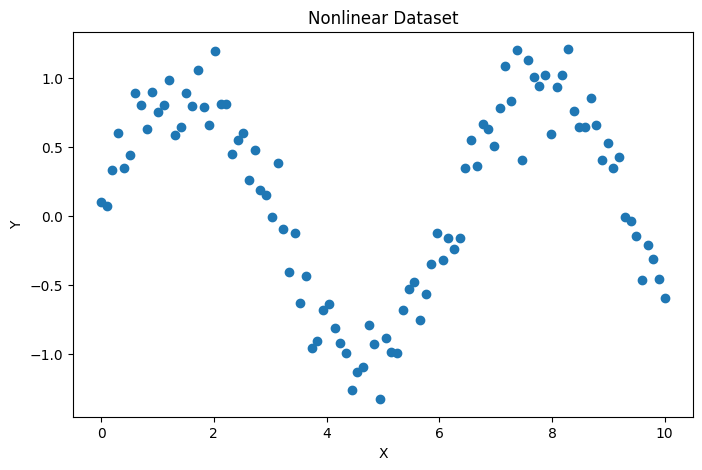

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Create nonlinear dataset
X = np.linspace(0,10,100)
y = np.sin(X) + np.random.normal(0,0.2,100)

plt.figure(figsize=(8,5))
plt.scatter(X,y)

plt.title("Nonlinear Dataset")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

Explanation:

This dataset cannot be fitted well by a straight line.

In [2]:
def gaussian_weight(x_query, X, tau):

    weights = np.exp(-(X - x_query)**2 / (2 * tau**2))

    return weights

Explanation:

This function assigns importance to nearby points.

In [3]:
def lwlr_predict(x_query, X, y, tau):

    weights = gaussian_weight(x_query, X, tau)

    W = np.diag(weights)

    X_matrix = np.vstack([np.ones(len(X)), X]).T

    theta = np.linalg.pinv(X_matrix.T @ W @ X_matrix) @ X_matrix.T @ W @ y

    prediction = theta[0] + theta[1] * x_query

    return prediction

What this does:

Computes weights

Builds weighted regression

Predicts output

In [4]:
tau = 0.5

predictions = []

for x in X:

    pred = lwlr_predict(x, X, y, tau)

    predictions.append(pred)

Each prediction uses a local regression model.

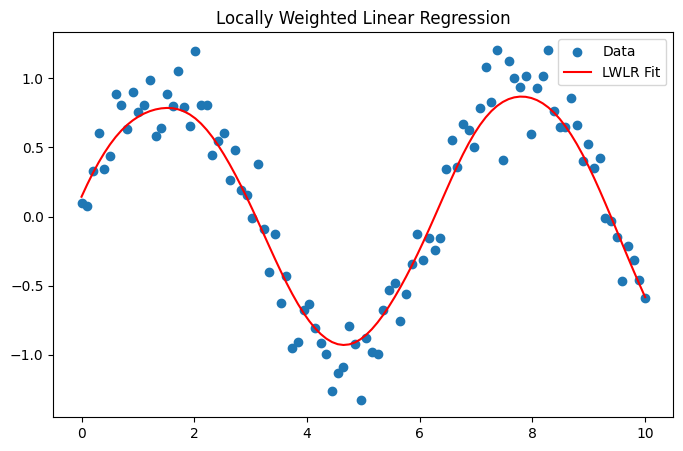

In [5]:
plt.figure(figsize=(8,5))

plt.scatter(X,y,label="Data")

plt.plot(X,predictions,color="red",label="LWLR Fit")

plt.legend()

plt.title("Locally Weighted Linear Regression")

plt.show()

You will see:

Data is nonlinear

LWLR curve follows the pattern

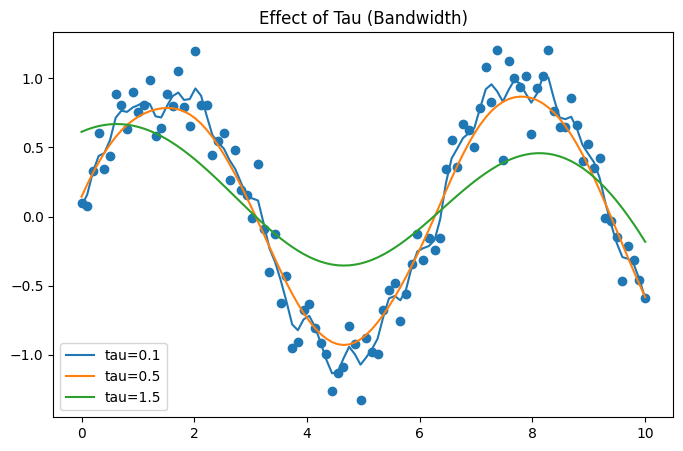

In [6]:
taus = [0.1,0.5,1.5]

plt.figure(figsize=(8,5))

plt.scatter(X,y)

for tau in taus:

    preds = [lwlr_predict(x,X,y,tau) for x in X]

    plt.plot(X,preds,label=f"tau={tau}")

plt.legend()

plt.title("Effect of Tau (Bandwidth)")

plt.show()

Interpretation:

Small τ → very flexible model

Large τ → smoother model

# EXTRA KNOWLEDGE — NORMAL EQUATION

"""
Normal Equation provides a direct mathematical solution
to linear regression without gradient descent.

Formula:

θ = (XᵀX)^−1 Xᵀy

It works well for small datasets but becomes very expensive
when the number of features is large.

Modern machine learning systems instead use Gradient Descent.
"""

# SUMMARY

"""
Locally Weighted Linear Regression improves linear regression
by allowing the model to focus on nearby data.

Key ideas:

1. Each prediction builds its own regression model
2. Nearby data points get higher importance
3. Gaussian weighting controls influence

Advantages:

Captures nonlinear patterns
Flexible model

Limitations:

Computationally expensive
Must compute regression for every query point
"""